In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

# Load the dataset (make sure you have uploaded the file first)
df = pd.read_csv("/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Display dataset information
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [2]:
# Step 2: Data Cleaning
print("Missing values per column:\n", df.isnull().sum())

# Drop duplicates if any
df = df.drop_duplicates()

print("\nNew dataset shape after removing duplicates:", df.shape)


Missing values per column:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

New dataset shape after removing duplicates: (69057, 22)


In [3]:
# Step 3: Separate features and target column
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']


In [4]:
from sklearn.model_selection import train_test_split

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (55245, 21)
Testing set shape: (13812, 21)


In [5]:
#  Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify numeric columns
numeric_features = X_train.columns

# Create numeric data transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)
])

print("✅ Preprocessing pipeline is ready!")


✅ Preprocessing pipeline is ready!


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Build full pipeline: preprocessing + model
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Train the model
dt_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = dt_pipeline.predict(X_test)

# Evaluate model
print("✅ Decision Tree Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


✅ Decision Tree Model Results
Accuracy: 0.7247321169997104

Confusion Matrix:
 [[4584 2208]
 [1594 5426]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.74      0.67      0.71      6792
         1.0       0.71      0.77      0.74      7020

    accuracy                           0.72     13812
   macro avg       0.73      0.72      0.72     13812
weighted avg       0.73      0.72      0.72     13812



In [7]:
# Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define parameters to test
param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 9, 12]
}

# Create GridSearchCV
grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters and score
print("🔍 Best Parameters Found:", grid_search.best_params_)
print("🔝 Best Cross-Validation Accuracy:", grid_search.best_score_)

# Evaluate with test data
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("\nTest Accuracy with Best Model:", accuracy_score(y_test, y_pred_best))


🔍 Best Parameters Found: {'classifier__criterion': 'entropy', 'classifier__max_depth': 7}
🔝 Best Cross-Validation Accuracy: 0.737062177572631

Test Accuracy with Best Model: 0.7342890240370692


✅ DBSCAN Results:
Number of clusters found: 277
Number of noise points: 30995
Silhouette Score: -0.07876831853572401


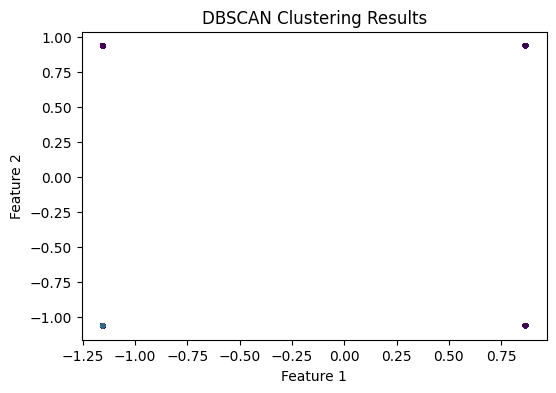

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Apply preprocessing (scaling)
X_scaled = preprocessor.fit_transform(X)

# Run DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

# Analyze clustering results
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("✅ DBSCAN Results:")
print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

# Silhouette score (only if >1 cluster)
if n_clusters > 1:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score not applicable")

# Plot clusters
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=8)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [9]:
# Save preprocessed dataset for later use
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df['Diabetes_binary'] = y.values

scaled_df.to_csv("/content/cleaned_scaled_diabetes_data.csv", index=False)
print("✅ Cleaned and scaled dataset saved as 'cleaned_scaled_diabetes_data.csv'")


✅ Cleaned and scaled dataset saved as 'cleaned_scaled_diabetes_data.csv'


In [10]:
# Visualizations and Analysis
import seaborn as sns
from sklearn import tree

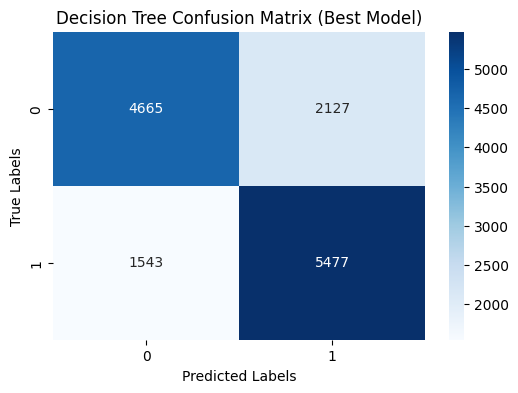

In [11]:
# --- Confusion Matrix Heatmap ---
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix (Best Model)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()





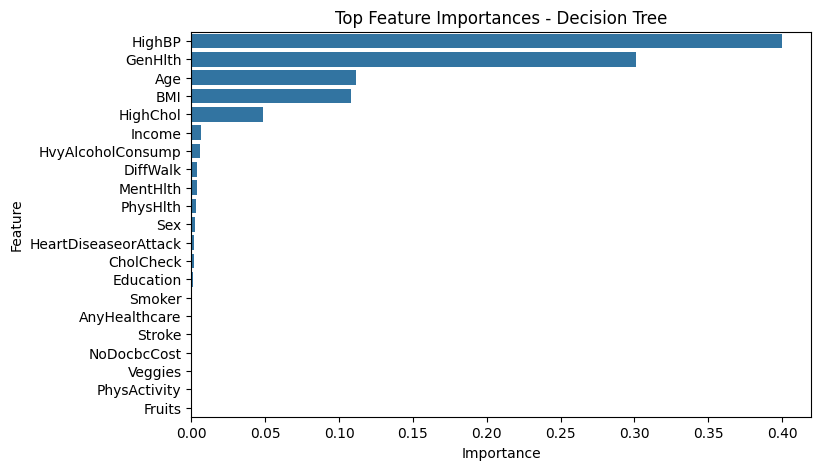

In [12]:
# --- Feature Importance Plot ---
best_clf = best_model.named_steps['classifier']
feature_importances = best_clf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Top Feature Importances - Decision Tree")
plt.show()

/tmp/ipython-input-3025568596.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before Tuning', 'After Tuning'], y=[base_acc, best_acc], palette='mako')


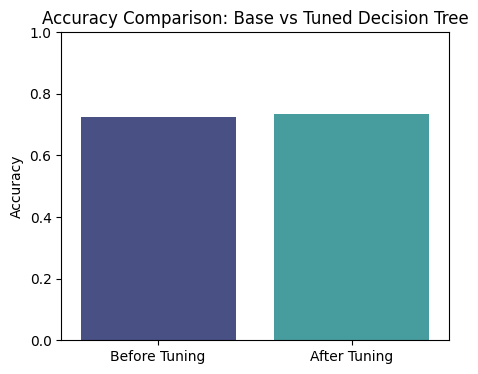

In [13]:
# --- Accuracy Comparison ---
base_model = DecisionTreeClassifier(max_depth=5, random_state=42)
base_model.fit(preprocessor.fit_transform(X_train), y_train)
y_pred_base = base_model.predict(preprocessor.transform(X_test))
base_acc = accuracy_score(y_test, y_pred_base)
best_acc = accuracy_score(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.barplot(x=['Before Tuning', 'After Tuning'], y=[base_acc, best_acc], palette='mako')
plt.title("Accuracy Comparison: Base vs Tuned Decision Tree")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

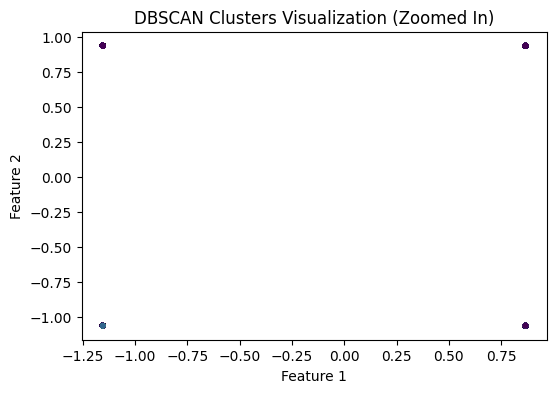

In [14]:
# --- DBSCAN Cluster Visualization ---
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=10)
plt.title("DBSCAN Clusters Visualization (Zoomed In)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()